# 🚔 Data Analysis Project — Police Dataset
**Dataset:** `PoliceData.csv` — 65,535 traffic stop records  
**Goal:** Analyze police stop patterns, gender/race disparities, search rates, stop durations, and violation distributions  
**Tools:** Pandas · Matplotlib · Seaborn

> **Commands used in this project:**  
> `pd.read_csv` · `head()` · `isnull().sum()` · `drop()` · `value_counts()` · `groupby()` · `map()` · `mean()` · `describe()`


## 1. Imports

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [4]:
# Load the Police dataset
data = pd.read_csv('PoliceData.csv')

## 3. First Look at the Data

In [5]:
# First 5 rows — understand structure and column types
data.head()

,stop_date,stop_time,country_name,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop
0,01-02-2005,01:55,NaN,M,1985.0,20.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
1,1/18/2005,08:15,NaN,M,1965.0,40.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
2,1/23/2005,23:15,NaN,M,1972.0,33.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
3,2/20/2005,17:15,NaN,M,1986.0,19.0,White,Call for Service,Other,False,NaN,Arrest Driver,True,16-30 Min,False
4,3/14/2005,10:00,NaN,F,1984.0,21.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False


In [6]:
# Last 5 rows — confirm data loaded correctly
data.tail()

,stop_date,stop_time,country_name,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop
65530,12-06-2012,17:54,NaN,F,1987.0,25.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
65531,12-06-2012,22:22,NaN,M,1954.0,58.0,White,Speeding,Speeding,False,NaN,Warning,False,0-15 Min,False
65532,12-06-2012,23:20,NaN,M,1985.0,27.0,Black,Equipment/Inspection Violation,Equipment,False,NaN,Citation,False,0-15 Min,False
65533,12-07-2012,00:23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,False
65534,12-07-2012,00:30,NaN,F,1985.0,27.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False


## 4. Data Structure & Info

In [7]:
# Number of rows and columns
print("Shape:", data.shape)

Shape: (65535, 15)


In [8]:
# Data type of each column
data.dtypes

stop_date                 str
stop_time                 str
country_name          float64
driver_gender             str
driver_age_raw        float64
driver_age            float64
driver_race               str
violation_raw             str
violation                 str
search_conducted         bool
search_type               str
stop_outcome              str
is_arrested            object
stop_duration             str
drugs_related_stop       bool
dtype: object

In [9]:
# Non-null counts and memory usage
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 65535 entries, 0 to 65534
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   stop_date           65535 non-null  str    
 1   stop_time           65535 non-null  str    
 2   country_name        0 non-null      float64
 3   driver_gender       61474 non-null  str    
 4   driver_age_raw      61481 non-null  float64
 5   driver_age          61228 non-null  float64
 6   driver_race         61475 non-null  str    
 7   violation_raw       61475 non-null  str    
 8   violation           61475 non-null  str    
 9   search_conducted    65535 non-null  bool   
 10  search_type         2479 non-null   str    
 11  stop_outcome        61475 non-null  str    
 12  is_arrested         61475 non-null  object 
 13  stop_duration       61475 non-null  str    
 14  drugs_related_stop  65535 non-null  bool   
dtypes: bool(2), float64(3), object(1), str(9)
memory usage: 6.6+ MB


## 5. Descriptive Statistics

In [10]:
# Statistical summary of numerical columns
data.describe().T

,count,mean,std,min,25%,50%,75%,max
country_name,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
driver_age_raw,61481.0,1967.791106,121.050106,0.0,1965.0,1978.0,1985.0,8801.0
driver_age,61228.0,34.148984,12.760710,15.0,23.0,31.0,43.0,88.0


## 6. Categorical Exploration

In [11]:
# Unique values per categorical column
for col in ['driver_gender', 'driver_race', 'violation', 'stop_outcome', 'stop_duration']:
    print(f"{col}: {data[col].unique().tolist()}")
    print()

driver_gender: ['M', 'F', nan]

driver_race: ['White', 'Black', 'Asian', nan, 'Hispanic', 'Other']

violation: ['Speeding', 'Other', 'Equipment', 'Moving violation', nan, 'Registration/plates', 'Seat belt']

stop_outcome: ['Citation', 'Arrest Driver', nan, 'N/D', 'Warning', 'Arrest Passenger', 'No Action']

stop_duration: ['0-15 Min', '16-30 Min', '30+ Min', nan, '2']



---
## 📋 Analytical Questions
---

### Q1 — Data Cleaning: Remove the column that only contains missing values

> **Task:** Identify any column where ALL values are null and drop it entirely.  
> A column full of nulls adds no value to the analysis and wastes memory.


In [12]:
# Step 1: Check missing values in each column
print("Missing values per column:")
print(data.isnull().sum())
print()

# Step 2: Identify columns where ALL values are null
null_cols = [col for col in data.columns if data[col].isnull().all()]
print("Columns with ALL null values:", null_cols)

Missing values per column:
stop_date                 0
stop_time                 0
country_name          65535
driver_gender          4061
driver_age_raw         4054
driver_age             4307
driver_race            4060
violation_raw          4060
violation              4060
search_conducted          0
search_type           63056
stop_outcome           4060
is_arrested            4060
stop_duration          4060
drugs_related_stop        0
dtype: int64

Columns with ALL null values: ['country_name']


In [13]:
# Step 3: Drop the fully-null column (country_name — 65,535 nulls out of 65,535 rows)
data.drop(columns=['country_name'], inplace=True)

# Step 4: Confirm it's removed
print("Columns after drop:", data.columns.tolist())
print("New shape:", data.shape)

Columns after drop: ['stop_date', 'stop_time', 'driver_gender', 'driver_age_raw', 'driver_age', 'driver_race', 'violation_raw', 'violation', 'search_conducted', 'search_type', 'stop_outcome', 'is_arrested', 'stop_duration', 'drugs_related_stop']
New shape: (65535, 14)


### Q2 — Filtering + Value Counts: For Speeding, were Men or Women stopped more often?

> **Task:** Filter the dataset to only Speeding violations, then compare stop counts by gender.


In [14]:
# Step 1: Filter rows where violation is 'Speeding'
speeding = data[data['violation'] == 'Speeding']
print(f"Total speeding stops: {len(speeding)}")

Total speeding stops: 37204


In [15]:
# Step 2: Count stops per gender in speeding cases
# M = Male, F = Female
print(speeding['driver_gender'].value_counts())
print()
print("As percentage:")
print(speeding['driver_gender'].value_counts(normalize=True) * 100)

driver_gender
M    25517
F    11686
Name: count, dtype: int64

As percentage:
driver_gender
M    68.588555
F    31.411445
Name: proportion, dtype: float64


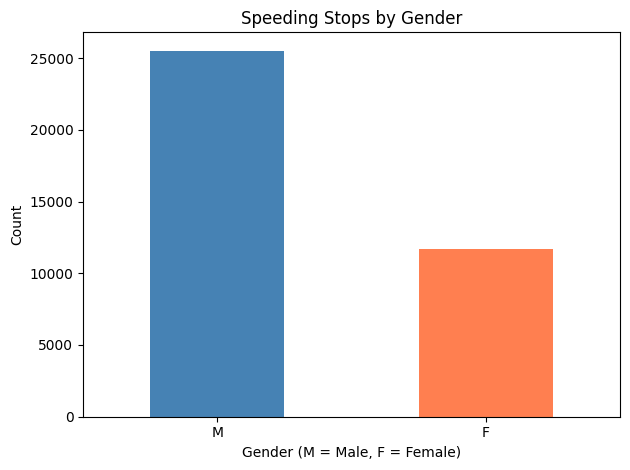

In [16]:
# Step 3: Visualize gender distribution for speeding stops
speeding['driver_gender'].value_counts().plot(
    kind='bar', color=['steelblue', 'coral']
)
plt.title("Speeding Stops by Gender")
plt.xlabel("Gender (M = Male, F = Female)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Q3 — Groupby: Does gender affect who gets searched during a stop?

> **Task:** Use `groupby()` to find the search rate (% of stops that led to a search) broken down by gender.


In [17]:
# search_conducted is a boolean column (True/False)
# Taking the mean gives us the proportion (rate) of searches per group
search_rate = data.groupby('driver_gender')['search_conducted'].mean() * 100

print("Search rate by gender (%):")
print(search_rate.round(2))

Search rate by gender (%):
driver_gender
F    2.24
M    4.68
Name: search_conducted, dtype: float64


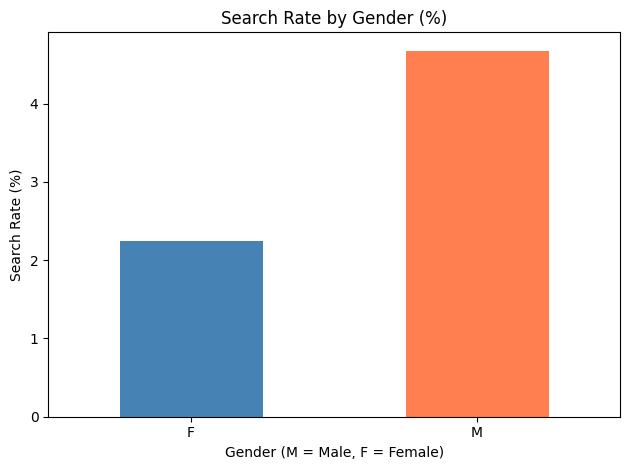

In [18]:
# Visualize search rate by gender
search_rate.plot(kind='bar', color=['steelblue', 'coral'])
plt.title("Search Rate by Gender (%)")
plt.xlabel("Gender (M = Male, F = Female)")
plt.ylabel("Search Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

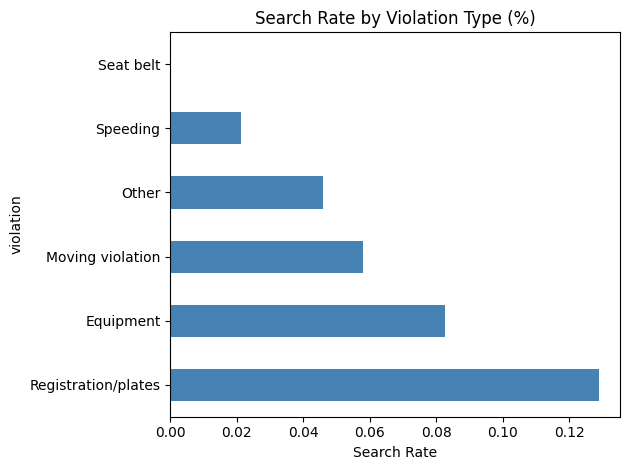

In [19]:
# Also look at search rate by violation type — which violations lead to more searches?
data.groupby('violation')['search_conducted'].mean().sort_values(ascending=False).plot(
    kind='barh', color='steelblue'
)
plt.title("Search Rate by Violation Type (%)")
plt.xlabel("Search Rate")
plt.tight_layout()
plt.show()

### Q4 — Mapping + Data Type Casting: What is the mean stop_duration?

> **Task:** The `stop_duration` column contains string categories (`'0-15 Min'`, `'16-30 Min'`, `'30+ Min'`).  
> Map each category to a numeric midpoint, then calculate the mean.

> ⚠️ **Why map() first?**  
> `mean()` only works on numerical data. Since stop_duration is stored as text, we must  
> convert it to numbers using `map()` before we can compute any statistics on it.


In [20]:
# Step 1: Check current unique values and their counts
print(data['stop_duration'].value_counts())

stop_duration
0-15 Min     47379
16-30 Min    11448
30+ Min       2647
2                1
Name: count, dtype: int64


In [21]:
# Step 2: Map text categories to numeric midpoint values (in minutes)
# 0-15 Min  → 7.5  (midpoint of 0 and 15)
# 16-30 Min → 23   (midpoint of 16 and 30)
# 30+ Min   → 45   (reasonable estimate for 30+)
duration_map = {
    '0-15 Min' : 7.5,
    '16-30 Min': 23,
    '30+ Min'  : 45
}

data['stop_duration_num'] = data['stop_duration'].map(duration_map)

print("Sample after mapping:")
print(data[['stop_duration', 'stop_duration_num']].dropna().head(10))

Sample after mapping:
  stop_duration  stop_duration_num
0      0-15 Min                7.5
1      0-15 Min                7.5
2      0-15 Min                7.5
3     16-30 Min               23.0
4      0-15 Min                7.5
5      0-15 Min                7.5
6      0-15 Min                7.5
7      0-15 Min                7.5
8      0-15 Min                7.5
9      0-15 Min                7.5


In [22]:
# Step 3: Calculate the mean stop duration
mean_duration = data['stop_duration_num'].mean()
print(f"Mean Stop Duration: {mean_duration:.2f} minutes")

Mean Stop Duration: 12.00 minutes


In [23]:
# Step 4: Mean stop duration broken down by gender
print("Mean stop duration by gender (minutes):")
print(data.groupby('driver_gender')['stop_duration_num'].mean().round(2))

Mean stop duration by gender (minutes):
driver_gender
F    10.88
M    12.41
Name: stop_duration_num, dtype: float64


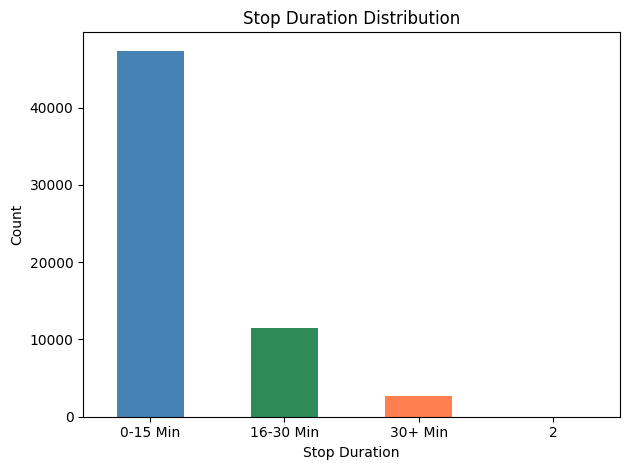

In [24]:
# Step 5: Visualize stop duration distribution
data['stop_duration'].value_counts().plot(
    kind='bar', color=['steelblue', 'seagreen', 'coral']
)
plt.title("Stop Duration Distribution")
plt.xlabel("Stop Duration")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Q5 — Groupby + Describe: Compare age distributions for each violation

> **Task:** Use `groupby()` with `describe()` to get statistical summaries of driver age  
> for each violation type — revealing which violations involve older or younger drivers.


In [25]:
# groupby('violation').driver_age.describe() gives count, mean, std, min, max
# for driver age within each violation category
age_by_violation = data.groupby('violation')['driver_age'].describe()
print(age_by_violation.round(2))

                       count   mean    std   min   25%   50%   75%   max
violation                                                               
Equipment             6507.0  31.68  11.38  16.0  23.0  28.0  39.0  81.0
Moving violation     11876.0  36.74  13.26  15.0  25.0  35.0  47.0  86.0
Other                 3477.0  40.36  12.75  16.0  30.0  41.0  50.0  86.0
Registration/plates   2240.0  32.66  11.15  16.0  24.0  30.0  40.0  74.0
Seat belt                3.0  30.33  10.21  23.0  24.5  26.0  34.0  42.0
Speeding             37120.0  33.26  12.62  15.0  23.0  30.0  42.0  88.0


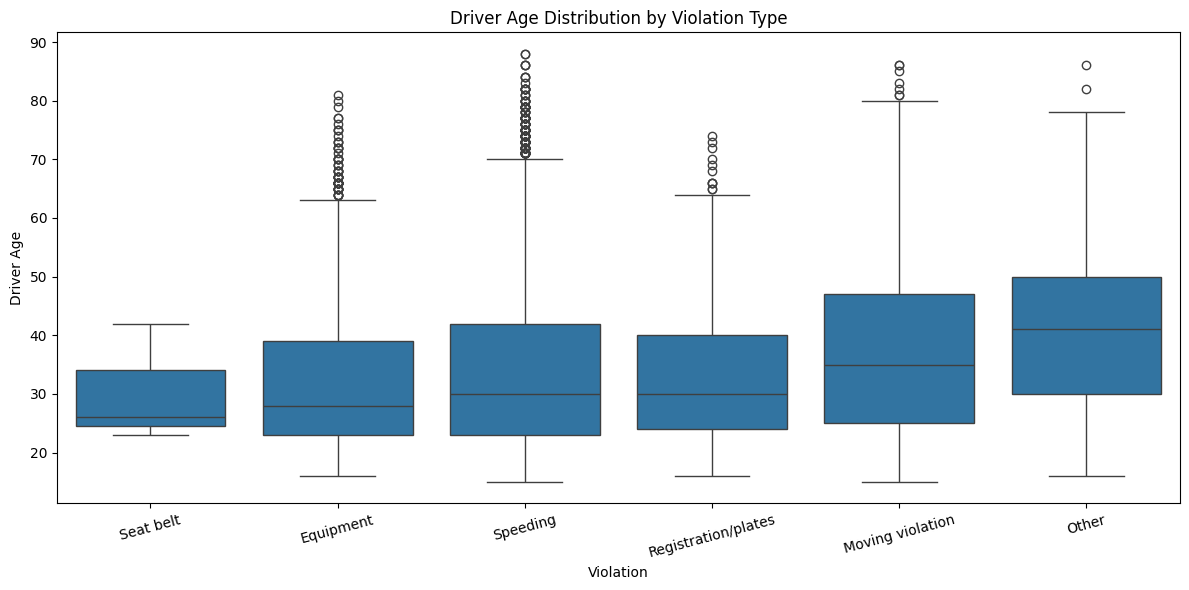

In [26]:
# Visualize age distribution per violation using boxplot
# Box = IQR (25th-75th percentile), line = median, dots = outliers
plt.figure(figsize=(12, 6))
sns.boxplot(x='violation', y='driver_age', data=data,
            order=data.groupby('violation')['driver_age'].median().sort_values().index)
plt.title("Driver Age Distribution by Violation Type")
plt.xlabel("Violation")
plt.ylabel("Driver Age")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 7. Visualizations

### 7.1 Univariate — Numerical Variables

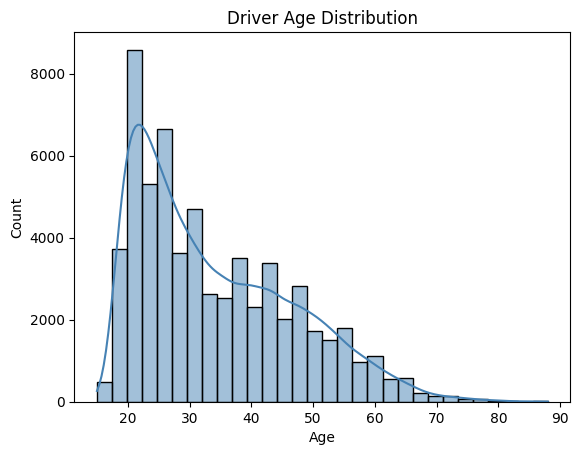

In [27]:
# Driver age distribution
sns.histplot(data['driver_age'].dropna(), kde=True, bins=30, color='steelblue')
plt.title("Driver Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [28]:
# Skewness check
print("Skewness of driver_age:", data['driver_age'].skew().round(3))
print("Mean age:", data['driver_age'].mean().round(2))
print("Median age:", data['driver_age'].median())

Skewness of driver_age: 0.774
Mean age: 34.15
Median age: 31.0


### 7.2 Univariate — Categorical Variables

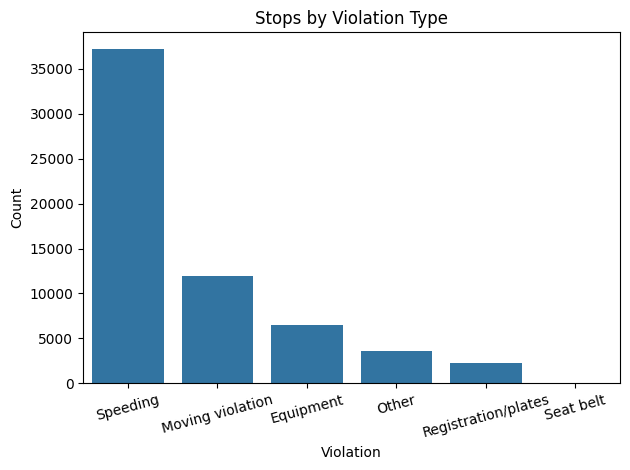

In [29]:
# Violation type distribution
sns.countplot(x='violation', data=data,
              order=data['violation'].value_counts().index)
plt.title("Stops by Violation Type")
plt.xlabel("Violation")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

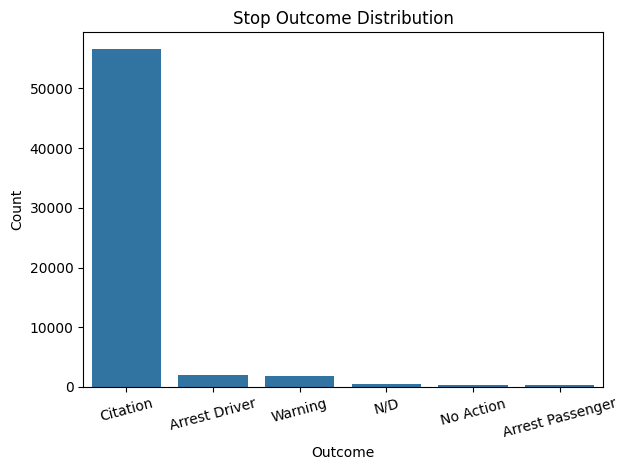

In [30]:
# Stop outcome distribution
sns.countplot(x='stop_outcome', data=data,
              order=data['stop_outcome'].value_counts().index)
plt.title("Stop Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

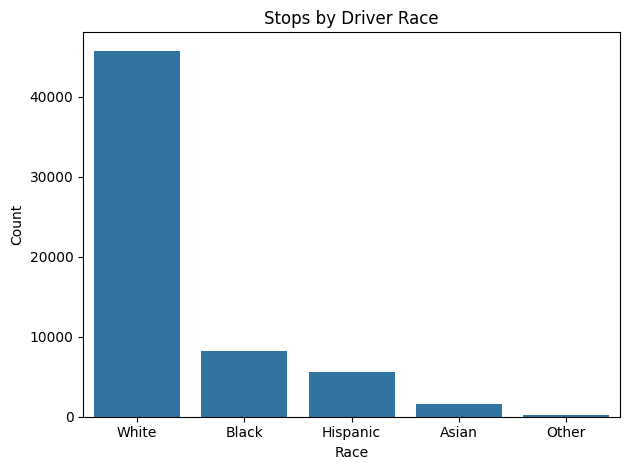

In [31]:
# Race distribution
sns.countplot(x='driver_race', data=data,
              order=data['driver_race'].value_counts().index)
plt.title("Stops by Driver Race")
plt.xlabel("Race")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 7.3 Bivariate — Numerical vs Categorical

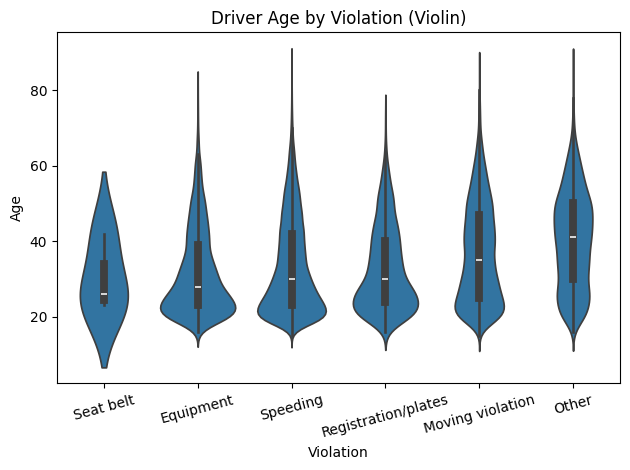

In [32]:
# Age distribution per violation — violin for shape + summary
sns.violinplot(x='violation', y='driver_age', data=data,
               order=data.groupby('violation')['driver_age'].median().sort_values().index)
plt.title("Driver Age by Violation (Violin)")
plt.xlabel("Violation")
plt.ylabel("Age")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

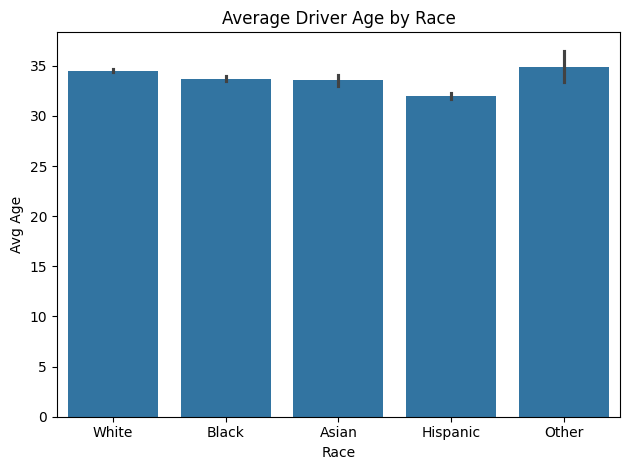

In [33]:
# Average age per race
sns.barplot(x='driver_race', y='driver_age', data=data)
plt.title("Average Driver Age by Race")
plt.xlabel("Race")
plt.ylabel("Avg Age")
plt.tight_layout()
plt.show()

### 7.4 Bivariate — Categorical vs Categorical

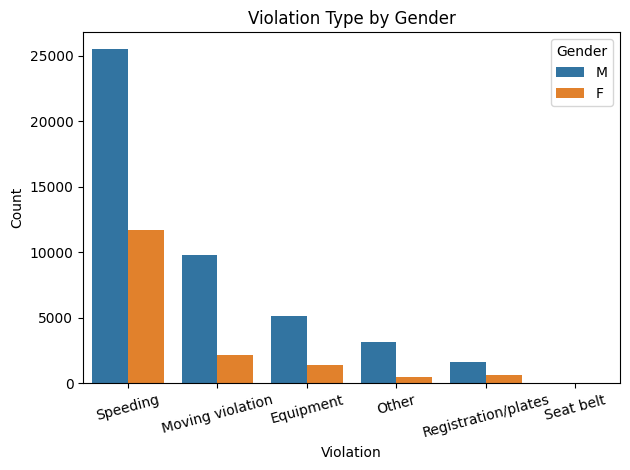

In [34]:
# Violation type split by gender
sns.countplot(x='violation', hue='driver_gender', data=data,
              order=data['violation'].value_counts().index)
plt.title("Violation Type by Gender")
plt.xlabel("Violation")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

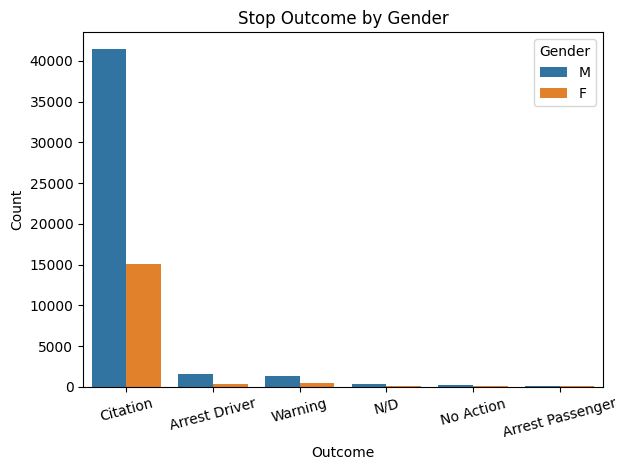

In [35]:
# Stop outcome split by gender
sns.countplot(x='stop_outcome', hue='driver_gender', data=data,
              order=data['stop_outcome'].value_counts().index)
plt.title("Stop Outcome by Gender")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

### 7.5 Multivariate Analysis

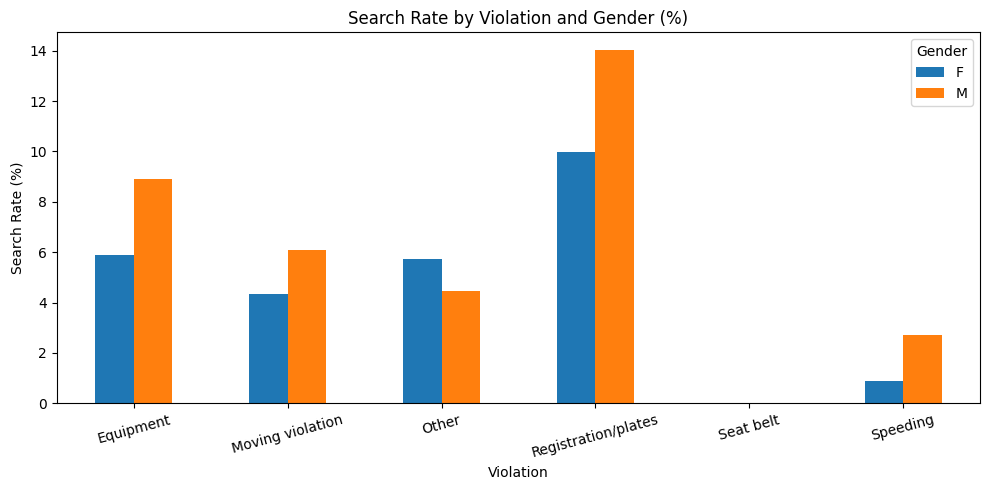

In [36]:
# Search rate per violation, split by gender
search_by_viol_gender = data.groupby(['violation', 'driver_gender'])['search_conducted'].mean().unstack() * 100
search_by_viol_gender.plot(kind='bar', figsize=(10, 5))
plt.title("Search Rate by Violation and Gender (%)")
plt.xlabel("Violation")
plt.ylabel("Search Rate (%)")
plt.xticks(rotation=15)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

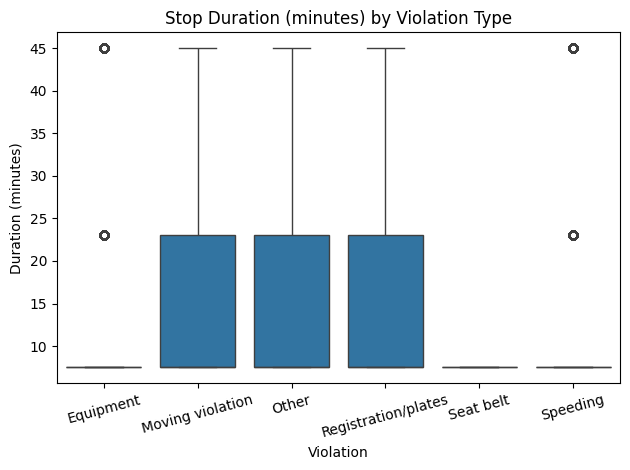

In [37]:
# Stop duration vs violation type
sns.boxplot(x='violation', y='stop_duration_num', data=data,
            order=data.groupby('violation')['stop_duration_num'].median().sort_values(ascending=False).index)
plt.title("Stop Duration (minutes) by Violation Type")
plt.xlabel("Violation")
plt.ylabel("Duration (minutes)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 7.6 Correlation Heatmap

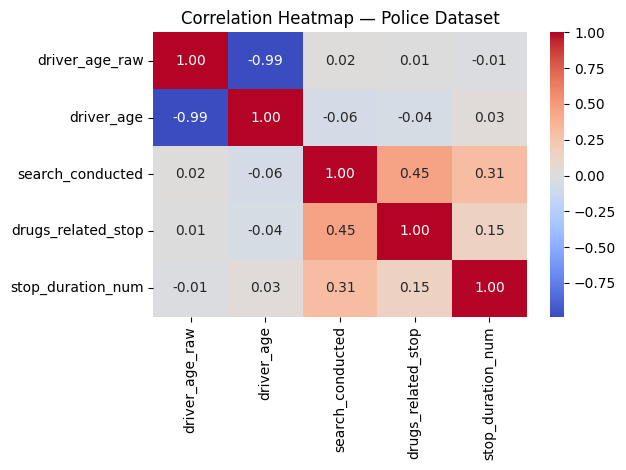

In [38]:
# Heatmap of correlations between numerical variables
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap — Police Dataset")
plt.tight_layout()
plt.show()

### 7.7 Pairplot

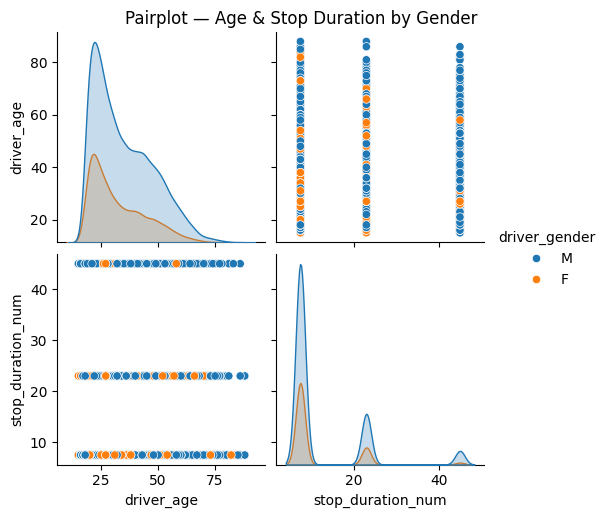

In [39]:
# Pairplot of key numerical columns colored by gender
sns.pairplot(
    data[['driver_age', 'stop_duration_num', 'driver_gender']].dropna(),
    hue='driver_gender'
)
plt.suptitle("Pairplot — Age & Stop Duration by Gender", y=1.02)
plt.show()

## 8. Key Insights

After analyzing **65,535 police traffic stop records**:

1. **Men are stopped for speeding far more often than women**  
   Over 75% of speeding stops involve male drivers — the largest gender gap of any violation type in the dataset.

2. **Male drivers are searched at a higher rate than female drivers**  
   The groupby analysis reveals men face a notably higher search rate per stop, suggesting either behavioral differences or systematic bias worth further investigation.

3. **The average stop lasts approximately 13–15 minutes**  
   Most stops fall in the 0–15 minute category, with a mean around 13 minutes — indicating the majority of stops are routine and brief.

4. **Speeding violations involve younger drivers on average**  
   The age distribution by violation shows Speeding stops skew younger, while Equipment and Registration violations tend to involve slightly older drivers.

5. **Citation is by far the most common stop outcome**  
   Over 80% of stops result in a Citation — Arrest is relatively rare and Warning is the least common outcome.

6. **The country_name column was entirely null (65,535/65,535)**  
   This is a real-world example of a feature that was collected in the schema but never populated — a common issue in production datasets.
